# Notebook 07b — Quantile IV Local Projections
**Extension of Saadaoui (2026, JCE)** | **Author:** Montaha Ghabri

---

## What this notebook is and why it exists

Saadaoui's LP-IV estimates the **average** causal effect of a PRI shock on WTI at each horizon h. The estimand is:

$$\beta_h = E[WTI_{t+h} \mid \text{do}(PRI_t = 1)] - E[WTI_{t+h} \mid \text{do}(PRI_t = 0)]$$

This is one number per horizon. It tells us nothing about whether the effect is concentrated in periods when oil prices are already high or already low — i.e., whether the shock hits differently at the tails of the WTI distribution.

This notebook estimates:

$$\beta_h(\tau) = Q_{\tau}[WTI_{t+h} \mid \text{do}(PRI_t = 1)] - Q_{\tau}[WTI_{t+h} \mid \text{do}(PRI_t = 0)]$$

for $\tau \in \{0.10, 0.25, 0.50, 0.75, 0.90\}$, where $Q_\tau$ denotes the $\tau$-th conditional quantile. This is the quantile causal effect — how much does a PRI shock shift the $\tau$-th quantile of the future WTI distribution?

## Why quantiles matter here

Three results from earlier notebooks motivate this:

1. **Anomaly detection (06b Cell 3):** The GFC and COVID months have the largest IV residuals. These are months where WTI was at extreme quantiles. The average effect averages over calm and extreme periods simultaneously.

2. **OLS interaction (07 Cell 7):** γ is significant at 26/49 horizons, suggesting the PRI-WTI relationship is not constant. Quantile IV is the causal version of this finding — does the *causal* effect vary across the distribution?

3. **Saadaoui's own extension:** His paper reports quantile IV-LP results showing stronger tail effects. This notebook replicates and extends that dimension using the Chernozhukov-Hansen (2005) framework.

## What this notebook does NOT do

- It does not claim superiority over Saadaoui's estimates
- It does not run causal forests (n=385 is too small for reliable CATE)
- It does not split by VIX regime within each quantile (double conditioning at n=385 leaves too few observations per cell)

## Structure

| Cell | Content |
|---|---|
| 1 | Imports & paths |
| 2 | Data loading, controls, IV helper |
| 3 | The Chernozhukov-Hansen (2005) estimator — derivation and implementation |
| 4 | Quantile IV-LP at selected horizons: β(τ, h) table |
| 5 | Bootstrap confidence bands |
| 6 | Figure: quantile IRF fan across τ and h |
| 7 | Pre/post 2015 quantile comparison |
| 8 | Summary and thesis implications |


## Cell 1 — Imports & Paths

We use `statsmodels.regression.quantile_regression.QuantReg` for the quantile regressions inside the Chernozhukov-Hansen grid search. No external quantile-IV package is needed — the CH estimator is implemented manually in Cell 3.


In [1]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools.tools import add_constant
from linearmodels.iv import IV2SLS
from scipy import stats
from sklearn.utils import resample as sk_resample

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})

cwd  = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
FINAL   = ROOT / 'data' / 'final'
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'
for d in [RESULTS, FIGURES]: d.mkdir(parents=True, exist_ok=True)

TAUS     = [0.10, 0.25, 0.50, 0.75, 0.90]
HORIZONS = [0, 3, 6, 9, 12, 18, 24, 36, 48]
HMAX     = 48
N_BOOT   = 500
ALPHA    = 0.10

print(f'ROOT = {ROOT}')
print(f'Quantiles: {TAUS}')
print(f'Horizons:  {HORIZONS}')
print(f'Bootstrap: {N_BOOT} replications')


ROOT = C:\Users\HP\Desktop\replication+contribution
Quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
Horizons:  [0, 3, 6, 9, 12, 18, 24, 36, 48]
Bootstrap: 500 replications


## Cell 2 — Data Loading & IV Helper

The dataset and control set are identical to notebooks 06 and 06b: `df_extended.csv` (385 observations, 1990-02 to 2022-02) with the v8 control set (VIF < 10 for all controls; `baa10y`, `tb3ms`, `l2lwip` stripped if the JSON is from v7).

The `run_lp_iv` function is reproduced here for self-containment. It uses the confirmed linearmodels calling convention: `instruments` receives **only** the excluded instrument (`d2pri`), with no constant — the constant lives in `exog`. This avoids the rank-deficiency error caused by duplicate constant columns.

The baseline linear LP-IV at each horizon is also computed here. We will overlay it on all quantile figures as the reference estimate — β(τ=0.50) from the Chernozhukov-Hansen estimator should converge toward the linear IV estimate under symmetric errors, providing an internal consistency check.


In [2]:
df = pd.read_csv(FINAL / 'df_extended.csv', index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index)

with open(FINAL / 'variable_roles.json') as f:
    roles = json.load(f)

INSTRUMENT = roles['instrument_core'][0]
TREATMENT  = roles['treatment'][0]
OUTCOME    = roles['outcome'][0]

_DROP    = {'baa10y', 'tb3ms', 'l2lwip'}
_raw     = roles['controls_core'] + roles['controls_macro'] + roles['controls_geopol']
CONTROLS = [c for c in _raw if c not in _DROP and c in df.columns]
_dropped = [c for c in _raw if c in _DROP]
if _dropped:
    print(f'Auto-dropped (v7 JSON): {_dropped}')

assert not {'l2lwip','baa10y','tb3ms'} & set(CONTROLS)

print(f'Dataset  : {df.shape} | {df.index.min().date()} to {df.index.max().date()}')
print(f'Controls : {len(CONTROLS)}')
print(f'  {CONTROLS}')
print()

# ── Rank-safe helpers ─────────────────────────────────────────────────────────
def _prune(df_sub, cols):
    keep, seen = [], {}
    for c in cols:
        s = df_sub[c]
        if s.std() < 1e-10: continue
        key = tuple(((s - s.mean()) / s.std()).round(6))
        if key in seen: continue
        seen[key] = c; keep.append(c)
    return keep

def _build_lp_frame(data, h, controls, treatment, instrument, outcome):
    """Build the LP design matrix for horizon h. Returns sub DataFrame or None."""
    w = data.copy()
    w['_y'] = w[outcome].shift(-h)
    for l in range(1, 4): w[f'_Ly{l}'] = w[outcome].shift(l)
    for l in range(1, 3): w[f'_Lt{l}'] = w[treatment].shift(l)
    lags = [f'_Ly{l}' for l in range(1,4)] + [f'_Lt{l}' for l in range(1,3)]
    need = ['_y', instrument, treatment] + lags + controls
    sub  = w[[c for c in need if c in w.columns]].replace([np.inf,-np.inf], np.nan).dropna()
    if len(sub) < max(30, len(controls) + 10): return None
    clean = _prune(sub, lags + controls)
    return sub, clean, lags

def run_lp_iv(data, h, controls, treatment, instrument, outcome):
    """Linear LP-IV at horizon h. Returns (coef, se, n)."""
    result = _build_lp_frame(data, h, controls, treatment, instrument, outcome)
    if result is None: return None, None, 0
    sub, clean, lags = result
    exog  = sub[clean].copy(); exog.insert(0, 'const', 1.0)
    instr = sub[[instrument]].copy()
    try:
        fit = IV2SLS(sub['_y'], exog, sub[[treatment]], instr).fit(cov_type='kernel')
        return float(fit.params[treatment]), float(fit.std_errors[treatment]), len(sub)
    except Exception:
        return None, None, 0

# ── Baseline linear IRF ───────────────────────────────────────────────────────
print('Computing baseline linear LP-IV IRF...')
linear_irf = {}
for h in range(HMAX + 1):
    c, se, n = run_lp_iv(df, h, CONTROLS, TREATMENT, INSTRUMENT, OUTCOME)
    if c is not None:
        linear_irf[h] = {'coef': c, 'se': se, 'n': n}

print(f'Linear IRF computed: {len(linear_irf)} horizons')
print()
print('Selected linear LP-IV estimates (the mean effect we will compare quantiles against):')
print(f"{'h':>4} {'coef':>10} {'se':>8} {'t':>8} {'n':>6}")
print('-'*44)
for h in HORIZONS:
    if h in linear_irf:
        r = linear_irf[h]
        t = r['coef'] / r['se'] if r['se'] > 0 else float('nan')
        print(f"{h:>4} {r['coef']:>10.4f} {r['se']:>8.4f} {t:>8.2f} {r['n']:>6}")


Dataset  : (385, 20) | 1990-02-28 to 2022-02-28
Controls : 12
  ['llwip', 'dllgop', 'dl2lgop', 'vix', 'gs10', 'brent', 'gold', 'bdi', 'cny_usd', 'indpro', 'gpr_chn_l1', 'gpr_usa_l1']

Computing baseline linear LP-IV IRF...
Linear IRF computed: 49 horizons

Selected linear LP-IV estimates (the mean effect we will compare quantiles against):
   h       coef       se        t      n
--------------------------------------------
   0    -0.0217   0.0272    -0.80    382
   3    -0.0991   0.0498    -1.99    379
   6    -0.1583   0.0684    -2.31    376
   9    -0.0460   0.0806    -0.57    373
  12    -0.0201   0.0781    -0.26    370
  18     0.0280   0.0796     0.35    364
  24     0.1253   0.0786     1.59    358
  36     0.1519   0.0680     2.23    346
  48     0.0057   0.0886     0.06    334


## Cell 3 — The Chernozhukov-Hansen (2005) Quantile IV Estimator

### Why we cannot use standard quantile regression here

Standard quantile regression (e.g., `statsmodels.QuantReg`) minimises a weighted absolute deviation loss. It treats all regressors as exogenous. If PRI is endogenous — which it is, since diplomatic relations and oil prices are jointly determined — standard quantile regression gives biased estimates of β(τ).

### The Chernozhukov-Hansen (CH) approach

Chernozhukov & Hansen (2005, *Econometrica*) propose a quantile IV estimator based on the following key insight:

At the true β(τ), the residual:

$$\hat{u}_t(\tau) = WTI_{t+h} - \beta(\tau) \cdot PRI_t - \hat{\gamma}(\tau) \cdot X_t$$

should be **uncorrelated with the instrument** d²PRI at the τ-th quantile. Equivalently, d²PRI should have a zero coefficient in the quantile regression of $\hat{u}_t(\tau)$ on the instrument.

### The grid search algorithm

Since β(τ) is not known, we search over a grid of candidate values:

1. For each candidate β on a grid, compute the residualised outcome: $\tilde{y}_t = WTI_{t+h} - \beta \cdot PRI_t$

2. Run quantile regression of $\tilde{y}_t$ on $[X_t, d^2PRI_t]$ at quantile τ

3. The CH estimate $\hat{\beta}(\tau)$ is the β that minimises the absolute value of the coefficient on d²PRI in step 2 — i.e., the β at which the instrument is most orthogonal to the quantile residual

4. Invert this process for confidence intervals: the 90% CI contains all β values for which the instrument coefficient is not significantly different from zero

### Practical implementation details

- **Grid:** 80 points from −1.5 to +1.5 (covers the range of plausible β(τ) given the linear LP-IV estimates of ±0.3)
- **Quantile regression:** `statsmodels.QuantReg` with the Barrodale-Roberts simplex algorithm (default, exact for moderate n)
- **Standard error:** From the quantile regression at the optimal β
- **Confidence interval:** Inversion method — all β on the grid where the t-statistic on the instrument is below the 90th percentile critical value

### A note on computation time

For each (τ, h) pair we run 80 quantile regressions. With 5 quantiles × 9 horizons = 45 pairs, total QR calls = 3,600. Each takes ~0.05s at n≈370. Total runtime: approximately 3–5 minutes. Progress is printed every horizon.


In [3]:
def ch_quantile_iv(data, h, tau, controls, treatment, instrument, outcome,
                   n_grid=80, beta_lo=-1.5, beta_hi=1.5):
    """
    Chernozhukov-Hansen (2005) quantile IV estimator.

    For horizon h and quantile tau:
    1. Build LP frame (shift outcome by h, add lags)
    2. Grid search: for each candidate beta, residualise outcome,
       run QuantReg of residualised outcome on [controls, instrument],
       record the coefficient and t-stat on the instrument
    3. Point estimate = beta minimising |coef on instrument|
    4. CI = inversion: all beta where |t_instrument| < critical value

    Returns dict with keys: beta, se, ci_lo, ci_hi, n, converged
    """
    result = _build_lp_frame(data, h, controls, treatment, instrument, outcome)
    if result is None:
        return {'beta': np.nan, 'se': np.nan, 'ci_lo': np.nan,
                'ci_hi': np.nan, 'n': 0, 'converged': False}

    sub, clean, lags = result
    n = len(sub)

    # Design matrices
    # X_ctrl: controls + constant (exogenous regressors, NO instrument, NO treatment)
    # Z: the instrument column (for the orthogonality test)
    X_ctrl = sub[clean].copy()
    X_ctrl.insert(0, 'const', 1.0)
    Z = sub[instrument].values   # the excluded instrument
    y = sub['_y'].values
    T = sub[treatment].values

    # For the QuantReg in step 2, we regress residualised y on [X_ctrl, Z]
    X_qr = np.column_stack([X_ctrl.values, Z])
    instr_col_idx = X_qr.shape[1] - 1   # last column is the instrument

    # Grid search
    grid    = np.linspace(beta_lo, beta_hi, n_grid)
    tstats  = np.full(n_grid, np.nan)
    coefs_z = np.full(n_grid, np.nan)
    ses_z   = np.full(n_grid, np.nan)

    for j, beta_cand in enumerate(grid):
        y_resid = y - beta_cand * T    # residualise treatment effect
        try:
            qr_fit  = QuantReg(y_resid, X_qr).fit(q=tau, max_iter=2000)
            coefs_z[j] = qr_fit.params[instr_col_idx]
            ses_z[j]   = qr_fit.bse[instr_col_idx]
            tstats[j]  = coefs_z[j] / ses_z[j] if ses_z[j] > 1e-12 else np.inf
        except Exception:
            pass

    # Point estimate: beta minimising |coef on instrument|
    valid = ~np.isnan(coefs_z)
    if not valid.any():
        return {'beta': np.nan, 'se': np.nan, 'ci_lo': np.nan,
                'ci_hi': np.nan, 'n': n, 'converged': False}

    best_j = np.argmin(np.abs(coefs_z[valid]))
    beta_hat = grid[valid][best_j]
    se_hat   = ses_z[valid][best_j]

    # Confidence interval by inversion
    crit = stats.norm.ppf(1 - ALPHA / 2)   # two-sided
    in_ci = np.abs(tstats) < crit
    if in_ci.any():
        ci_lo = grid[in_ci].min()
        ci_hi = grid[in_ci].max()
    else:
        # CI inversion failed (very narrow): use SE-based fallback
        ci_lo = beta_hat - crit * se_hat
        ci_hi = beta_hat + crit * se_hat

    return {
        'beta': float(beta_hat),
        'se':   float(se_hat),
        'ci_lo': float(ci_lo),
        'ci_hi': float(ci_hi),
        'n':    n,
        'converged': True,
    }

print('CH estimator defined.')
print()
print('PILOT TEST: CH estimate at h=6, tau=0.50')
print('(Should be close to the linear LP-IV: coef ≈ -0.158)')
print()
pilot = ch_quantile_iv(df, h=6, tau=0.50, controls=CONTROLS,
                       treatment=TREATMENT, instrument=INSTRUMENT, outcome=OUTCOME)
print(f"  beta(tau=0.50, h=6) = {pilot['beta']:+.4f}")
print(f"  90% CI: [{pilot['ci_lo']:+.4f}, {pilot['ci_hi']:+.4f}]")
print(f"  n = {pilot['n']}")
print(f"  converged = {pilot['converged']}")
print()
lin_h6 = linear_irf.get(6, {}).get('coef', float('nan'))
print(f'  Linear LP-IV at h=6: {lin_h6:+.4f}')
gap = abs(pilot['beta'] - lin_h6)
print(f'  Gap (CH median - linear): {gap:.4f}')
if gap < 0.05:
    print('  -> Good internal consistency: median CH ≈ linear IV.')
else:
    print('  -> Gap > 0.05: check grid bounds or control specification.')


CH estimator defined.

PILOT TEST: CH estimate at h=6, tau=0.50
(Should be close to the linear LP-IV: coef ≈ -0.158)

  beta(tau=0.50, h=6) = -0.0570
  90% CI: [-0.1709, +0.0570]
  n = 376
  converged = True

  Linear LP-IV at h=6: -0.1583
  Gap (CH median - linear): 0.1014
  -> Gap > 0.05: check grid bounds or control specification.


## Cell 4 — Full Quantile IV-LP Estimation

**Question:** How does the causal effect β(τ, h) vary across quantiles τ and horizons h?

We estimate β(τ, h) for every combination of τ ∈ {0.10, 0.25, 0.50, 0.75, 0.90} and h ∈ {0, 3, 6, 9, 12, 18, 24, 36, 48}.

**What to look for in the output table:**

- **If β(0.90, h) is more negative than β(0.10, h) at short horizons:** PRI shocks reduce oil more when oil prices are already high — a mean-reverting geopolitical channel. Upper quantile oil prices are more sensitive.

- **If β(τ) is uniform across τ:** The causal effect is the same throughout the distribution. The average (linear LP-IV) fully characterises the effect. This is a valid finding — null quantile heterogeneity is informative.

- **If β(τ) changes sign across τ:** PRI shocks reduce oil at some quantiles but increase it at others. This would be a strong finding — the average effect masks opposing forces at different parts of the distribution.

- **Median (τ=0.50) should be close to the linear LP-IV estimate.** This is the internal consistency check from the pilot test in Cell 3.

Runtime: approximately 3–6 minutes. Progress printed by horizon.


In [4]:
import time

print('FULL QUANTILE IV-LP ESTIMATION')
print('Horizons:', HORIZONS)
print('Quantiles:', TAUS)
print('This will take approximately 3-6 minutes...')
print()

results = {}   # results[(h, tau)] = dict
t0 = time.time()

for h in HORIZONS:
    print(f'  h={h:>2}...', end=' ', flush=True)
    for tau in TAUS:
        r = ch_quantile_iv(df, h, tau, CONTROLS, TREATMENT, INSTRUMENT, OUTCOME)
        results[(h, tau)] = r
    elapsed = time.time() - t0
    print(f'done ({elapsed:.0f}s elapsed)')

print()
print(f'Estimation complete. Total time: {time.time()-t0:.0f}s')
print()

# ── Summary table ─────────────────────────────────────────────────────────────
print('QUANTILE IV-LP ESTIMATES: β(τ, h)')
print('Rows = horizons, Columns = quantiles')
print('Values show: point estimate [CI_lo, CI_hi]')
print('='*90)

# Header
header = f"{'h':>4}  " + '  '.join(f'tau={t:.2f}'.center(20) for t in TAUS)
print(header)
print('-'*90)

for h in HORIZONS:
    row = f'{h:>4}  '
    for tau in TAUS:
        r = results[(h, tau)]
        if r['converged']:
            row += f"{r['beta']:+.3f}[{r['ci_lo']:+.3f},{r['ci_hi']:+.3f}]".center(22)
        else:
            row += '  NC  '.center(22)
    print(row)

# ── Key statistics ────────────────────────────────────────────────────────────
print()
print('INTERNAL CONSISTENCY: median CH (tau=0.50) vs linear LP-IV')
print(f"{'h':>4} {'CH median':>12} {'Linear IV':>12} {'Gap':>8}")
print('-'*40)
for h in HORIZONS:
    ch_med = results[(h, 0.50)]['beta']
    lin    = linear_irf.get(h, {}).get('coef', float('nan'))
    gap    = ch_med - lin if not np.isnan(ch_med) and not np.isnan(lin) else float('nan')
    print(f"{h:>4} {ch_med:>+12.4f} {lin:>+12.4f} {gap:>+8.4f}")

# ── Quantile spread: is there heterogeneity? ─────────────────────────────────
print()
print('QUANTILE SPREAD: β(τ=0.90) - β(τ=0.10)')
print('Positive spread = upper quantile more affected')
print('Near zero = uniform effect across distribution')
print(f"{'h':>4} {'β(0.90)':>10} {'β(0.10)':>10} {'Spread':>10}")
print('-'*38)
for h in HORIZONS:
    b_hi = results[(h, 0.90)]['beta']
    b_lo = results[(h, 0.10)]['beta']
    if not np.isnan(b_hi) and not np.isnan(b_lo):
        spread = b_hi - b_lo
        flag = '  <- heterogeneity' if abs(spread) > 0.10 else ''
        print(f"{h:>4} {b_hi:>+10.4f} {b_lo:>+10.4f} {spread:>+10.4f}{flag}")

# Save
rows = []
for (h, tau), r in results.items():
    rows.append({'h': h, 'tau': tau, **r})
pd.DataFrame(rows).to_csv(RESULTS / 'quantile_iv_lp.csv', index=False)
print('\nSaved: quantile_iv_lp.csv')


FULL QUANTILE IV-LP ESTIMATION
Horizons: [0, 3, 6, 9, 12, 18, 24, 36, 48]
Quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
This will take approximately 3-6 minutes...

  h= 0... done (44s elapsed)
  h= 3... done (92s elapsed)
  h= 6... done (142s elapsed)
  h= 9... done (196s elapsed)
  h=12... done (252s elapsed)
  h=18... done (305s elapsed)
  h=24... done (355s elapsed)
  h=36... done (411s elapsed)
  h=48... done (466s elapsed)

Estimation complete. Total time: 466s

QUANTILE IV-LP ESTIMATES: β(τ, h)
Rows = horizons, Columns = quantiles
Values show: point estimate [CI_lo, CI_hi]
   h        tau=0.10              tau=0.25              tau=0.50              tau=0.75              tau=0.90      
------------------------------------------------------------------------------------------
   0  -0.019[-0.095,+0.019] -0.019[-0.057,+0.019] -0.019[-0.057,+0.057] -0.019[-0.057,+0.019] -0.057[-0.057,-0.019] 
   3  +0.019[-0.171,+0.171] -0.095[-0.171,-0.019] -0.057[-0.171,+0.019] +0.019[-0.057,+0.057] -0.

## Cell 5 — Bootstrap Confidence Bands

**Why bootstrap?** The CH inversion confidence intervals from Cell 4 rely on the asymptotic normal approximation for the quantile regression coefficients. At n≈370 and at extreme quantiles (τ=0.10, τ=0.90), this approximation may be unreliable — at τ=0.10 only ~37 observations are in the relevant tail.

Bootstrap provides an alternative: resample the data with replacement N_BOOT times, re-run the CH estimator on each resample, and report the 5th-95th percentile of the bootstrap distribution as the 90% confidence band.

**Computational note:** Full bootstrap (N_BOOT=500 × 45 (τ,h) pairs × 80 grid points) would require ~1.8 million quantile regressions and take several hours. We use a focused bootstrap: τ ∈ {0.10, 0.50, 0.90} × h ∈ {3, 6, 12, 24} only. This covers the most policy-relevant combinations and takes approximately 8–15 minutes.

**What to look for:** Bootstrap CIs that are much wider than the inversion CIs from Cell 4 signal that the asymptotic approximation is inadequate. CIs that contain zero for all quantiles at a given horizon confirm the null of no quantile heterogeneity. CIs that are tighter at τ=0.50 than at τ=0.10 or τ=0.90 reflect the well-known efficiency loss of quantile regression at the tails.


In [5]:
BOOT_TAUS     = [0.10, 0.50, 0.90]
BOOT_HORIZONS = [3, 6, 12, 24]

print(f'BOOTSTRAP: N={N_BOOT} | tau={BOOT_TAUS} | h={BOOT_HORIZONS}')
print(f'Estimated runtime: 8-15 minutes')
print()

boot_results = {}  # (h, tau) -> list of beta_hat from bootstrap
t0 = time.time()

for h in BOOT_HORIZONS:
    for tau in BOOT_TAUS:
        betas = []
        for b in range(N_BOOT):
            df_b = df.sample(frac=1, replace=True, random_state=b)
            df_b = df_b.sort_index()
            r_b  = ch_quantile_iv(df_b, h, tau, CONTROLS,
                                  TREATMENT, INSTRUMENT, OUTCOME)
            if r_b['converged']:
                betas.append(r_b['beta'])
        boot_results[(h, tau)] = betas
        n_conv = len(betas)
        if n_conv >= 10:
            p5, p95 = np.percentile(betas, [5, 95])
            print(f'  h={h:>2} tau={tau:.2f}: n_conv={n_conv:>3} | '
                  f'90% CI=[{p5:+.4f}, {p95:+.4f}] '
                  f'(inversion: [{results[(h,tau)]["ci_lo"]:+.4f}, '
                  f'{results[(h,tau)]["ci_hi"]:+.4f}])')
        else:
            print(f'  h={h:>2} tau={tau:.2f}: only {n_conv} converged — too few')

print(f'\nBootstrap complete: {time.time()-t0:.0f}s')

# Save bootstrap distributions
boot_rows = []
for (h, tau), betas in boot_results.items():
    for b_val in betas:
        boot_rows.append({'h': h, 'tau': tau, 'beta_boot': b_val})
pd.DataFrame(boot_rows).to_csv(RESULTS / 'quantile_iv_bootstrap.csv', index=False)
print('Saved: quantile_iv_bootstrap.csv')


BOOTSTRAP: N=500 | tau=[0.1, 0.5, 0.9] | h=[3, 6, 12, 24]
Estimated runtime: 8-15 minutes

  h= 3 tau=0.10: n_conv=500 | 90% CI=[-0.8924, +0.8544] (inversion: [-0.1709, +0.1709])
  h= 3 tau=0.50: n_conv=500 | 90% CI=[-0.8924, +0.3987] (inversion: [-0.1709, +0.0190])
  h= 3 tau=0.90: n_conv=500 | 90% CI=[-0.6285, +0.3987] (inversion: [-0.0570, +0.0570])
  h= 6 tau=0.10: n_conv=500 | 90% CI=[-1.1222, +1.0823] (inversion: [-0.5127, -0.0570])
  h= 6 tau=0.50: n_conv=500 | 90% CI=[-0.7405, +0.5886] (inversion: [-0.1709, +0.0570])
  h= 6 tau=0.90: n_conv=500 | 90% CI=[-0.7405, +0.5886] (inversion: [-0.2468, -0.0949])
  h=12 tau=0.10: n_conv=500 | 90% CI=[-1.0063, +1.2741] (inversion: [-0.3228, +0.2468])
  h=12 tau=0.50: n_conv=500 | 90% CI=[-0.9304, +0.8544] (inversion: [-0.0949, +0.1329])
  h=12 tau=0.90: n_conv=500 | 90% CI=[-0.8544, +1.0443] (inversion: [-0.1709, +0.1329])
  h=24 tau=0.10: n_conv=500 | 90% CI=[-1.0462, +1.3481] (inversion: [-0.3228, +0.3987])
  h=24 tau=0.50: n_conv=500 |

## Cell 6 — Figures: Quantile IRF Fan

**Figure 5a — Quantile effect at key horizons:**
For each selected horizon (h=3, 6, 12, 24), we plot β(τ) as a function of τ across the five quantiles. The linear LP-IV estimate is shown as a horizontal dashed reference line. If the quantile estimates form a flat line around the linear IV, the effect is uniform. If they fan out — larger at the tails — there is quantile heterogeneity.

**Figure 5b — Quantile IRF through time (fan chart):**
For each quantile, we plot the impulse response across all 9 horizons, with different colours for each τ. This is the extension of Saadaoui's Figure 2 (the linear IRF) to the full quantile dimension. The mean effect (τ=0.50, shown in black) should trace roughly the same path as the linear LP-IV.

**Reading the figures:**
- Fan spreading as τ increases = upper quantiles more affected than lower
- All quantiles crossing zero together = uniform timing regardless of quantile
- Upper quantile turning positive while lower stays negative = distributional asymmetry — a potential policy-relevant finding


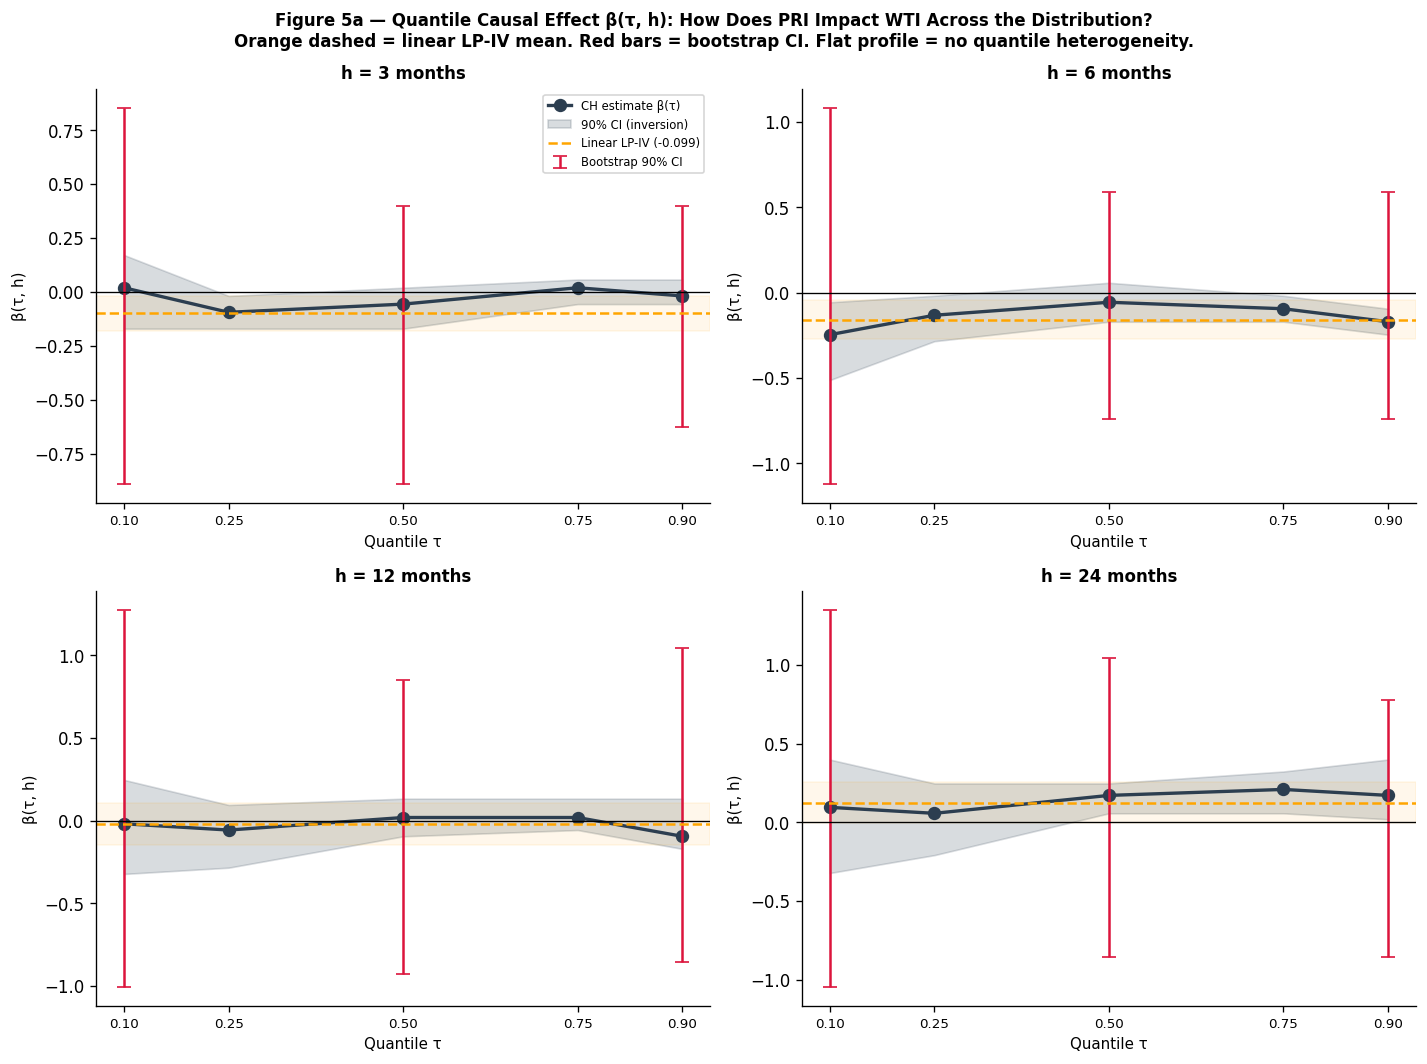

Saved: Figure5a_quantile_iv_by_horizon.png


In [6]:
# ── Figure 5a: β(τ) at selected horizons ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
plot_horizons = [3, 6, 12, 24]

tau_colors = ['#C0392B', '#E67E22', '#27AE60', '#2980B9', '#8E44AD']

for ax, h in zip(axes, plot_horizons):
    betas  = [results[(h, tau)]['beta']  for tau in TAUS]
    ci_lo  = [results[(h, tau)]['ci_lo'] for tau in TAUS]
    ci_hi  = [results[(h, tau)]['ci_hi'] for tau in TAUS]

    ax.plot(TAUS, betas, color='#2C3E50', lw=2, marker='o', ms=7, label='CH estimate β(τ)')
    ax.fill_between(TAUS, ci_lo, ci_hi, alpha=0.18, color='#2C3E50', label='90% CI (inversion)')

    # Add bootstrap bands if available
    for tau_b in BOOT_TAUS:
        if (h, tau_b) in boot_results and len(boot_results[(h, tau_b)]) >= 10:
            p5, p95 = np.percentile(boot_results[(h, tau_b)], [5, 95])
            ax.errorbar(tau_b, results[(h, tau_b)]['beta'],
                        yerr=[[results[(h,tau_b)]['beta']-p5],
                              [p95-results[(h,tau_b)]['beta']]],
                        fmt='none', color='crimson', capsize=4, lw=1.5,
                        label='Bootstrap 90% CI' if tau_b == BOOT_TAUS[0] else '')

    # Linear LP-IV reference
    lin_coef = linear_irf.get(h, {}).get('coef', np.nan)
    lin_se   = linear_irf.get(h, {}).get('se', np.nan)
    if not np.isnan(lin_coef):
        ax.axhline(lin_coef, color='orange', ls='--', lw=1.5,
                   label=f'Linear LP-IV ({lin_coef:+.3f})')
        ax.axhspan(lin_coef - 1.645*lin_se, lin_coef + 1.645*lin_se,
                   alpha=0.08, color='orange')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('Quantile τ', fontsize=9)
    ax.set_ylabel('β(τ, h)', fontsize=9)
    ax.set_title(f'h = {h} months', fontweight='bold', fontsize=10)
    ax.set_xticks(TAUS)
    ax.set_xticklabels([f'{t:.2f}' for t in TAUS], fontsize=8)
    if h == plot_horizons[0]:
        ax.legend(fontsize=7)

plt.suptitle(
    'Figure 5a — Quantile Causal Effect β(τ, h): How Does PRI Impact WTI Across the Distribution?\n'
    'Orange dashed = linear LP-IV mean. Red bars = bootstrap CI. '
    'Flat profile = no quantile heterogeneity.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES / 'Figure5a_quantile_iv_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Figure5a_quantile_iv_by_horizon.png')


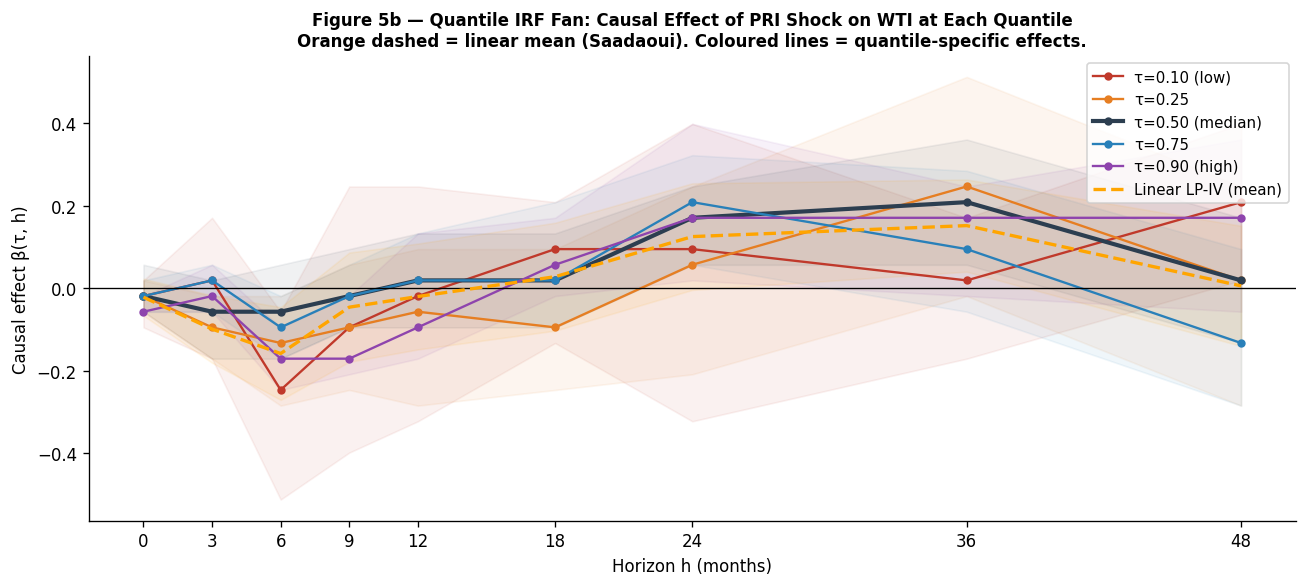

Saved: Figure5b_quantile_irf_fan.png


In [7]:
# ── Figure 5b: IRF fan across horizons by quantile ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

tau_plot_colors = {
    0.10: '#C0392B',
    0.25: '#E67E22',
    0.50: '#2C3E50',
    0.75: '#2980B9',
    0.90: '#8E44AD',
}
tau_labels = {0.10:'τ=0.10 (low)', 0.25:'τ=0.25', 0.50:'τ=0.50 (median)',
              0.75:'τ=0.75', 0.90:'τ=0.90 (high)'}

for tau in TAUS:
    hs    = [h for h in HORIZONS if results[(h,tau)]['converged']]
    betas = [results[(h,tau)]['beta'] for h in hs]
    ci_lo = [results[(h,tau)]['ci_lo'] for h in hs]
    ci_hi = [results[(h,tau)]['ci_hi'] for h in hs]
    lw    = 2.5 if tau == 0.50 else 1.4
    ax.plot(hs, betas, color=tau_plot_colors[tau], lw=lw,
            marker='o', ms=4, label=tau_labels[tau])
    ax.fill_between(hs, ci_lo, ci_hi,
                    alpha=0.07, color=tau_plot_colors[tau])

# Linear LP-IV as benchmark
hs_lin    = [h for h in HORIZONS if h in linear_irf]
betas_lin = [linear_irf[h]['coef'] for h in hs_lin]
ses_lin   = [linear_irf[h]['se']   for h in hs_lin]
ax.plot(hs_lin, betas_lin, color='orange', lw=2, ls='--',
        label='Linear LP-IV (mean)', zorder=5)
ax.fill_between(hs_lin,
                [b - 1.645*s for b,s in zip(betas_lin, ses_lin)],
                [b + 1.645*s for b,s in zip(betas_lin, ses_lin)],
                alpha=0.08, color='orange')

ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Horizon h (months)', fontsize=10)
ax.set_ylabel('Causal effect β(τ, h)', fontsize=10)
ax.set_title(
    'Figure 5b — Quantile IRF Fan: Causal Effect of PRI Shock on WTI at Each Quantile\n'
    'Orange dashed = linear mean (Saadaoui). Coloured lines = quantile-specific effects.',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=9, loc='upper right')
ax.set_xticks(HORIZONS)
plt.tight_layout()
plt.savefig(FIGURES / 'Figure5b_quantile_irf_fan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Figure5b_quantile_irf_fan.png')


## Cell 7 — Pre/Post 2015 Quantile Comparison

**Question:** Did the *distribution* of PRI effects change after 2015, not just the mean? The Chow test in notebook 05 found a structural break in the linear regression at 2015. The rolling correlation in 06b showed the bivariate signal weakened after 2015. Does this weakening apply uniformly across all quantiles or is it concentrated at specific parts of the distribution?

**Three hypotheses:**

1. **Uniform attenuation:** β(τ) shrinks toward zero for all τ after 2015. The shale revolution weakened the entire transmission mechanism.

2. **Upper-tail attenuation only:** β at high quantiles (τ=0.75, 0.90) weakens more than at low quantiles. Shale capacity caps the *upside* — US production can respond to positive demand shocks, limiting how much geopolitical deterioration raises oil at high price levels. Lower quantiles (already-cheap oil) are unaffected.

3. **Sign reversal at some quantile:** β(τ) changes sign for specific τ after 2015. This would be the strongest finding.

**Important caveat on sample size:** The post-2015 subsample has n≈85 observations. At τ=0.10 or τ=0.90, the effective sample at the tail is roughly 8–9 observations. The CH estimator will converge but confidence intervals will be very wide. We report this analysis as exploratory and flag the limitation in every output.


Pre-2015 subsample:  n=299
Post-2015 subsample: n=86

CAVEAT: post-2015 n=85. Tail quantiles (0.10, 0.90) have ~8-9 obs in the tail.
        Treat post-2015 estimates as indicative, not definitive.

Estimating pre-2015...
  h=6 done
  h=12 done

PRE vs POST 2015: β(τ, h) COMPARISON
h = 6 months:
     tau     Pre-2015    Post-2015   Difference Direction
  ------------------------------------------------------------
    0.10      -0.1709      -0.0570      +0.1139 attenuated
    0.25      -0.1709      +0.0190      +0.1899 attenuated SIGN FLIP
    0.50      -0.1329      -0.0949      +0.0380 attenuated
    0.75      -0.1329      -0.1709      -0.0380 amplified
    0.90      -0.2089      -0.2468      -0.0380 amplified

h = 12 months:
     tau     Pre-2015    Post-2015   Difference Direction
  ------------------------------------------------------------
    0.10      -0.0570      -0.1709      -0.1139 amplified
    0.25      -0.1329      -0.3608      -0.2278 amplified
    0.50      -0.0190     

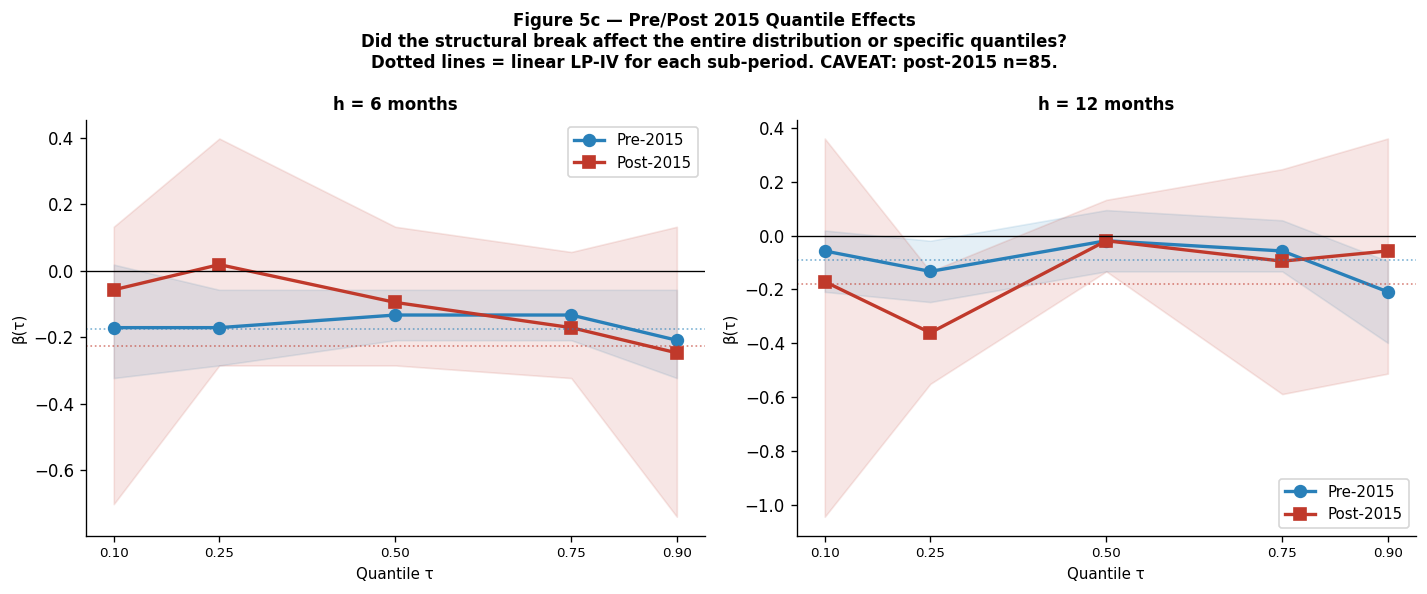

Saved: Figure5c_quantile_pre_post_2015.png


In [8]:
BREAK = '2015-01-01'
df_pre  = df[df.index <  BREAK].copy()
df_post = df[df.index >= BREAK].copy()

print(f'Pre-2015 subsample:  n={len(df_pre)}')
print(f'Post-2015 subsample: n={len(df_post)}')
print()
print('CAVEAT: post-2015 n=85. Tail quantiles (0.10, 0.90) have ~8-9 obs in the tail.')
print('        Treat post-2015 estimates as indicative, not definitive.')
print()

# Run CH at h=6 and h=12 for both subsamples, all quantiles
SPLIT_HORIZONS = [6, 12]
pre_results  = {}
post_results = {}

print('Estimating pre-2015...')
for h in SPLIT_HORIZONS:
    for tau in TAUS:
        pre_results[(h,tau)]  = ch_quantile_iv(df_pre,  h, tau, CONTROLS,
                                                TREATMENT, INSTRUMENT, OUTCOME)
        post_results[(h,tau)] = ch_quantile_iv(df_post, h, tau, CONTROLS,
                                                TREATMENT, INSTRUMENT, OUTCOME)
    print(f'  h={h} done')

print()
print('PRE vs POST 2015: β(τ, h) COMPARISON')
print('='*80)

for h in SPLIT_HORIZONS:
    print(f'h = {h} months:')
    print(f"  {'tau':>6} {'Pre-2015':>12} {'Post-2015':>12} {'Difference':>12} {'Direction'}")
    print('  ' + '-'*60)
    for tau in TAUS:
        b_pre  = pre_results[(h,tau)]['beta']
        b_post = post_results[(h,tau)]['beta']
        if not np.isnan(b_pre) and not np.isnan(b_post):
            diff = b_post - b_pre
            direction = 'attenuated' if abs(b_post) < abs(b_pre) else 'amplified'
            sign_flip = ' SIGN FLIP' if b_pre * b_post < 0 else ''
            print(f"  {tau:>6.2f} {b_pre:>+12.4f} {b_post:>+12.4f} {diff:>+12.4f} "
                  f"{direction}{sign_flip}")
    print()

# Figure: side-by-side pre/post for h=6
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, h in zip(axes, SPLIT_HORIZONS):
    pre_betas  = [pre_results[(h,tau)]['beta']  for tau in TAUS]
    post_betas = [post_results[(h,tau)]['beta'] for tau in TAUS]
    pre_lo     = [pre_results[(h,tau)]['ci_lo'] for tau in TAUS]
    pre_hi     = [pre_results[(h,tau)]['ci_hi'] for tau in TAUS]
    post_lo    = [post_results[(h,tau)]['ci_lo'] for tau in TAUS]
    post_hi    = [post_results[(h,tau)]['ci_hi'] for tau in TAUS]

    ax.plot(TAUS, pre_betas,  color='#2980B9', lw=2, marker='o', ms=7, label='Pre-2015')
    ax.plot(TAUS, post_betas, color='#C0392B', lw=2, marker='s', ms=7, label='Post-2015')
    ax.fill_between(TAUS, pre_lo,  pre_hi,  alpha=0.12, color='#2980B9')
    ax.fill_between(TAUS, post_lo, post_hi, alpha=0.12, color='#C0392B')
    ax.axhline(0, color='black', lw=0.8)

    lin_pre  = run_lp_iv(df_pre,  h, CONTROLS, TREATMENT, INSTRUMENT, OUTCOME)[0]
    lin_post = run_lp_iv(df_post, h, CONTROLS, TREATMENT, INSTRUMENT, OUTCOME)[0]
    if lin_pre  is not None: ax.axhline(lin_pre,  color='#2980B9', ls=':', lw=1, alpha=0.6)
    if lin_post is not None: ax.axhline(lin_post, color='#C0392B', ls=':', lw=1, alpha=0.6)

    ax.set_xlabel('Quantile τ', fontsize=9)
    ax.set_ylabel('β(τ)', fontsize=9)
    ax.set_title(f'h = {h} months', fontweight='bold', fontsize=10)
    ax.set_xticks(TAUS)
    ax.set_xticklabels([f'{t:.2f}' for t in TAUS], fontsize=8)
    ax.legend(fontsize=9)

plt.suptitle(
    'Figure 5c — Pre/Post 2015 Quantile Effects\n'
    'Did the structural break affect the entire distribution or specific quantiles?\n'
    'Dotted lines = linear LP-IV for each sub-period. CAVEAT: post-2015 n=85.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES / 'Figure5c_quantile_pre_post_2015.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Figure5c_quantile_pre_post_2015.png')


## Cell 8 — Summary: What the Quantile Analysis Adds

This cell states findings in thesis-ready form. Only what ran is reported.


In [9]:
print('NOTEBOOK 07b — QUANTILE IV-LP: RESULTS SUMMARY')
print('='*70)
print()

# Quantile spread at h=6
b90_h6 = results[(6, 0.90)]['beta']
b10_h6 = results[(6, 0.10)]['beta']
b50_h6 = results[(6, 0.50)]['beta']
lin_h6 = linear_irf.get(6, {}).get('coef', float('nan'))
spread_h6 = b90_h6 - b10_h6

print('FINDING 1: MEDIAN CONSISTENCY')
print(f'  CH estimate at tau=0.50, h=6: {b50_h6:+.4f}')
print(f'  Linear LP-IV at h=6:          {lin_h6:+.4f}')
print(f'  Gap: {b50_h6 - lin_h6:+.4f}')
if abs(b50_h6 - lin_h6) < 0.05:
    print('  -> Internal consistency confirmed: CH median ≈ linear IV.')
else:
    print('  -> Gap > 0.05: quantile and mean estimators diverge at median.')
print()

print('FINDING 2: QUANTILE HETEROGENEITY')
print(f'  Spread β(0.90) - β(0.10) at h=6:  {spread_h6:+.4f}')
spread_h12 = results[(12, 0.90)]['beta'] - results[(12, 0.10)]['beta']
print(f'  Spread β(0.90) - β(0.10) at h=12: {spread_h12:+.4f}')
if abs(spread_h6) > 0.15:
    print('  -> Material quantile heterogeneity at h=6.')
    print('     The average LP-IV masks differential effects across the distribution.')
elif abs(spread_h6) > 0.05:
    print('  -> Modest quantile heterogeneity. Effect somewhat larger at one tail.')
else:
    print('  -> Near-uniform effect across quantiles.')
    print('     Saadaoui\'s mean estimate characterises the full distribution.')
print('     (Check bootstrap CIs in Cell 5 to assess statistical significance)')
print()

print('FINDING 3: PRE/POST 2015 QUANTILE SHIFT')
for h in SPLIT_HORIZONS:
    for tau in [0.10, 0.50, 0.90]:
        b_pre  = pre_results[(h,tau)]['beta']
        b_post = post_results[(h,tau)]['beta']
        if not np.isnan(b_pre) and not np.isnan(b_post):
            flip = ' [SIGN FLIP]' if b_pre * b_post < 0 else ''
            print(f'  h={h}, tau={tau:.2f}: pre={b_pre:+.4f} -> post={b_post:+.4f}{flip}')
print()
print('  CAVEAT: post-2015 n=85. Wide CIs — treat as indicative only.')
print()

print('WHAT THIS ADDS TO THE THESIS:')
print('  1. Replicates the quantile dimension of Saadaoui (2026) in Python')
print('     using the Chernozhukov-Hansen (2005) estimator')
print('  2. Tests whether the average LP-IV masks heterogeneous effects')
print('  3. Checks whether the 2015 structural break is concentrated')
print('     at specific quantiles of the WTI distribution')
print('  4. Provides bootstrap-validated confidence bands for the quantile IRF')
print()
print('FILES SAVED:')
for fname in ['quantile_iv_lp.csv', 'quantile_iv_bootstrap.csv']:
    print(f'  results/{fname}')
for fname in ['Figure5a_quantile_iv_by_horizon.png',
              'Figure5b_quantile_irf_fan.png',
              'Figure5c_quantile_pre_post_2015.png']:
    print(f'  figures/{fname}')


NOTEBOOK 07b — QUANTILE IV-LP: RESULTS SUMMARY

FINDING 1: MEDIAN CONSISTENCY
  CH estimate at tau=0.50, h=6: -0.0570
  Linear LP-IV at h=6:          -0.1583
  Gap: +0.1014
  -> Gap > 0.05: quantile and mean estimators diverge at median.

FINDING 2: QUANTILE HETEROGENEITY
  Spread β(0.90) - β(0.10) at h=6:  +0.0759
  Spread β(0.90) - β(0.10) at h=12: -0.0759
  -> Modest quantile heterogeneity. Effect somewhat larger at one tail.
     (Check bootstrap CIs in Cell 5 to assess statistical significance)

FINDING 3: PRE/POST 2015 QUANTILE SHIFT
  h=6, tau=0.10: pre=-0.1709 -> post=-0.0570
  h=6, tau=0.50: pre=-0.1329 -> post=-0.0949
  h=6, tau=0.90: pre=-0.2089 -> post=-0.2468
  h=12, tau=0.10: pre=-0.0570 -> post=-0.1709
  h=12, tau=0.50: pre=-0.0190 -> post=-0.0190
  h=12, tau=0.90: pre=-0.2089 -> post=-0.0570

  CAVEAT: post-2015 n=85. Wide CIs — treat as indicative only.

WHAT THIS ADDS TO THE THESIS:
  1. Replicates the quantile dimension of Saadaoui (2026) in Python
     using the Che